# cell 1 cấu hình 


In [1]:
import os, math
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from scipy.optimize import linear_sum_assignment
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'

CSV_PATH = "/kaggle/input/datasets/phongkaggle/shelf-management-row/SHelf mAnagement Row/annotation.csv"  
IMG_DIR  = "/kaggle/input/datasets/phongkaggle/shelf-management-row/SHelf mAnagement Row/shelf_detection" 

IMG_H, IMG_W       = 512, 384
HOUGH_H, HOUGH_W   = 64, 48      # lưới không gian ảnh dùng để tính Hough transform (giảm để ma trận nhẹ)
NTHETA             = 11          # số góc theta quét quanh 90° (ngang)
THETA_WINDOW_DEG   = 10          # ±10 độ quanh phương ngang
NRHO               = 100         # "quantization level" -- giống Table 3 của paper (họ chọn 100)
BATCH_SIZE         = 8
EPOCHS             = 30
LR                 = 1e-4

# cell 2 load csv


In [2]:
df = pd.read_csv(CSV_PATH, sep=';')
df['ys'] = df['shelfCoord'].apply(lambda s: sorted(float(v) for v in str(s).split(',')))

# Bước 1: tách test set riêng (giữ nguyên, không dùng trong lúc train) -- giống "5000 ảnh test" của paper
trainval_df, test_df = train_test_split(df, test_size=0.15, random_state=42)

# Bước 2: chia phần còn lại thành train/val theo tỉ lệ 80:20 -- đúng như paper mô tả
train_df, val_df = train_test_split(trainval_df, test_size=0.2, random_state=42)

print(f"train={len(train_df)} | val={len(val_df)} | test={len(test_df)}")

train=15466 | val=3867 | test=3412


# cell 3 Hình học hough 

In [3]:
def build_hough_geometry(H, W, thetas_deg, nrho):
    """
    Với mỗi pixel (x,y) trên lưới HxW và mỗi góc theta, tính rho = x*cos(theta) + y*sin(theta).
    Rời rạc hóa rho thành nrho bins -> ma trận 'vote' (ntheta*nrho, H*W) biểu diễn
    ánh xạ CỐ ĐỊNH (không học) từ không gian ảnh (feature space) sang không gian tham số (theta, rho).
    """
    ys, xs = np.meshgrid(np.arange(H), np.arange(W), indexing='ij')
    xs = xs.astype(np.float32).ravel()
    ys = ys.astype(np.float32).ravel()
    thetas = np.deg2rad(thetas_deg)
    ntheta = len(thetas)
    rhos = np.stack([xs*np.cos(t) + ys*np.sin(t) for t in thetas], axis=0)  # (ntheta, H*W)
    rho_min, rho_max = rhos.min(), rhos.max()
    bins = np.linspace(rho_min, rho_max, nrho + 1)
    vote = np.zeros((ntheta, nrho, H*W), dtype=np.float32)
    for ti in range(ntheta):
        idx = np.clip(np.digitize(rhos[ti], bins) - 1, 0, nrho - 1)
        vote[ti, idx, np.arange(H*W)] = 1.0
    vote = vote.reshape(ntheta*nrho, H*W)
    counts = vote.sum(axis=1, keepdims=True); counts[counts == 0] = 1
    vote = vote / counts   # trung bình thay vì tổng, giúp ổn định giá trị theo số pixel mỗi bin

    bin_centers = (bins[:-1] + bins[1:]) / 2
    # Vì tại theta=90deg, rho = y đúng nghĩa -> dùng trực tiếp bin_centers để suy ngược ra y chuẩn hóa
    bin_to_y_norm = np.clip(bin_centers, 0, H - 1) / (H - 1)
    return torch.from_numpy(vote), bins, bin_to_y_norm

THETAS_DEG = np.linspace(90 - THETA_WINDOW_DEG, 90 + THETA_WINDOW_DEG, NTHETA)
VOTE_MATRIX, RHO_BINS, BIN_TO_Y_NORM = build_hough_geometry(HOUGH_H, HOUGH_W, THETAS_DEG, NRHO)

def y_norm_to_bin(y_norm):
    y_pixel = y_norm * (HOUGH_H - 1)
    b = np.clip(np.digitize(y_pixel, RHO_BINS) - 1, 0, NRHO - 1)
    return int(b)

# cell 4 dataset


In [4]:
SIGMA_BINS = 1.5  # độ rộng gaussian tính theo đơn vị bin của rho

def make_rho_heatmap(ys_norm):
    heatmap = np.zeros(NRHO, dtype=np.float32)
    xs = np.arange(NRHO)
    for y in ys_norm:
        center = y_norm_to_bin(y)
        heatmap = np.maximum(heatmap, np.exp(-((xs - center) ** 2) / (2 * SIGMA_BINS ** 2)))
    return heatmap

train_tf = A.Compose([A.Resize(IMG_H, IMG_W), A.HorizontalFlip(p=0.5),
                       A.RandomBrightnessContrast(p=0.3), A.Normalize(), ToTensorV2()])
val_tf   = A.Compose([A.Resize(IMG_H, IMG_W), A.Normalize(), ToTensorV2()])

class ShelfRowDataset(Dataset):
    def __init__(self, df, img_dir, transform):
        self.df = df.reset_index(drop=True); self.img_dir = img_dir; self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.cvtColor(cv2.imread(os.path.join(self.img_dir, row['filename'])), cv2.COLOR_BGR2RGB)
        img = self.transform(image=img)['image']
        heatmap = make_rho_heatmap(row['ys'])
        return img, torch.from_numpy(heatmap), row['ys']

def collate_fn(batch):
    imgs = torch.stack([b[0] for b in batch])
    heatmaps = torch.stack([b[1] for b in batch])
    ys_list = [b[2] for b in batch]   # giữ list gốc để evaluate (Hungarian matching)
    return imgs, heatmaps, ys_list

train_ds = ShelfRowDataset(train_df, IMG_DIR, train_tf)
val_ds   = ShelfRowDataset(val_df, IMG_DIR, val_tf)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, collate_fn=collate_fn)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, collate_fn=collate_fn)
test_ds = ShelfRowDataset(test_df, IMG_DIR, val_tf)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, collate_fn=collate_fn)

# cell 5 backbone Resnet50+ fpn

In [5]:
from torchvision.models.detection.backbone_utils import resnet_fpn_backbone

class ResNetFPNBackbone(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        self.body = resnet_fpn_backbone('resnet50', pretrained=pretrained, trainable_layers=3)
    def forward(self, x): return self.body(x)  # dict '0','1','2','3','pool'

class FeatureFuser(nn.Module):
    def __init__(self, channels=256):
        super().__init__()
        self.reduce = nn.Conv2d(channels, channels, 3, padding=1)
    def forward(self, feats):
        size = feats['0'].shape[-2:]
        fused = feats['0']
        for k in ['1', '2', '3']:
            fused = fused + F.interpolate(feats[k], size=size, mode='bilinear', align_corners=False)
        return self.reduce(fused)

# cell 6 Deep Hough Transform  + Model

In [6]:
class DeepHoughTransform(nn.Module):
    def __init__(self, in_channels, vote_matrix, ntheta, nrho, hough_h, hough_w, mid_channels=32):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d((hough_h, hough_w))   # đưa feature về lưới cố định (H,W) khớp vote_matrix
        self.reduce = nn.Conv2d(in_channels, mid_channels, 1)
        self.register_buffer('vote_matrix', vote_matrix)       # (ntheta*nrho, hough_h*hough_w) -- KHÔNG học
        self.ntheta, self.nrho = ntheta, nrho
        # CNN học trong không gian tham số (theta, rho)
        self.param_conv = nn.Sequential(
            nn.Conv2d(mid_channels, mid_channels, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, mid_channels, 3, padding=1), nn.ReLU(inplace=True),
        )
        self.head = nn.Sequential(
            nn.Conv1d(mid_channels, mid_channels, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv1d(mid_channels, 1, 1),
        )

    def forward(self, feat):
        feat = self.reduce(self.pool(feat))                 # (B, C, Hh, Ww)
        B, C, H, W = feat.shape
        flat = feat.reshape(B, C, H * W)
        # === feature space -> parameter space (Hough transform, ma trận cố định) ===
        hough = torch.matmul(flat, self.vote_matrix.t())     # (B, C, ntheta*nrho)
        hough = hough.view(B, C, self.ntheta, self.nrho)     # (B, C, theta, rho)
        hough = self.param_conv(hough)                       # học peak-detection trong không gian tham số
        # === reverse: gộp theta, chỉ giữ lại trục rho (vì rho ~ vị trí hàng khi theta~90) ===
        collapsed = hough.max(dim=2).values                  # (B, C, rho)
        logits = self.head(collapsed).squeeze(1)             # (B, rho) -- rho chính là "hàng"
        return logits

class ShelfRowNet(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        self.backbone = ResNetFPNBackbone(pretrained)
        self.fuser = FeatureFuser(256)
        self.dht = DeepHoughTransform(256, VOTE_MATRIX, NTHETA, NRHO, HOUGH_H, HOUGH_W)
    def forward(self, x):
        return self.dht(self.fuser(self.backbone(x)))

model = ShelfRowNet().to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:135: UserWarning: Using 'backbone_name' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 228MB/s]


# cell 7 Loss (focal loss heatmap)

In [7]:
def heatmap_focal_loss(pred_logits, target, alpha=2, beta=4):
    pred = torch.sigmoid(pred_logits).clamp(1e-4, 1 - 1e-4)
    pos_mask = target.eq(1).float(); neg_mask = target.lt(1).float()
    neg_weights = torch.pow(1 - target, beta)
    pos_loss = torch.log(pred) * torch.pow(1 - pred, alpha) * pos_mask
    neg_loss = torch.log(1 - pred) * torch.pow(pred, alpha) * neg_weights * neg_mask
    num_pos = pos_mask.sum().clamp(min=1)
    return -(pos_loss.sum() + neg_loss.sum()) / num_pos

# Cell 8 — Vòng lặp train

In [8]:
PATIENCE = 5          # số epoch chờ nếu val loss không cải thiện
best_val_loss = float('inf')
epochs_no_improve = 0
BEST_CKPT = "shelf_row_net_best.pth"

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

for epoch in range(EPOCHS):
    # ---- train ----
    model.train()
    train_loss = 0
    for imgs, heatmaps, _ in train_loader:
        imgs, heatmaps = imgs.to(device), heatmaps.to(device)
        optimizer.zero_grad()
        loss = heatmap_focal_loss(model(imgs), heatmaps)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    scheduler.step()

    # ---- validate ----
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for imgs, heatmaps, _ in val_loader:
            imgs, heatmaps = imgs.to(device), heatmaps.to(device)
            val_loss += heatmap_focal_loss(model(imgs), heatmaps).item()
    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

    # ---- early stopping ----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), BEST_CKPT)   # chỉ lưu khi val loss cải thiện
        print(f"  -> val_loss cải thiện, đã lưu checkpoint tốt nhất ({BEST_CKPT})")
    else:
        epochs_no_improve += 1
        print(f"  -> val_loss không cải thiện ({epochs_no_improve}/{PATIENCE})")
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping tại epoch {epoch+1} (best val_loss={best_val_loss:.4f})")
            break

# Nạp lại trọng số tốt nhất trước khi sang bước đánh giá (Cell 9)
model.load_state_dict(torch.load(BEST_CKPT))
model.to(device)

Epoch 1/30 | train_loss=0.2694 | val_loss=0.2335
  -> val_loss cải thiện, đã lưu checkpoint tốt nhất (shelf_row_net_best.pth)
Epoch 2/30 | train_loss=0.2170 | val_loss=0.2072
  -> val_loss cải thiện, đã lưu checkpoint tốt nhất (shelf_row_net_best.pth)
Epoch 3/30 | train_loss=0.2026 | val_loss=0.2212
  -> val_loss không cải thiện (1/5)
Epoch 4/30 | train_loss=0.1904 | val_loss=0.1877
  -> val_loss cải thiện, đã lưu checkpoint tốt nhất (shelf_row_net_best.pth)
Epoch 5/30 | train_loss=0.1794 | val_loss=0.1869
  -> val_loss cải thiện, đã lưu checkpoint tốt nhất (shelf_row_net_best.pth)
Epoch 6/30 | train_loss=0.1698 | val_loss=0.1845
  -> val_loss cải thiện, đã lưu checkpoint tốt nhất (shelf_row_net_best.pth)
Epoch 7/30 | train_loss=0.1623 | val_loss=0.2046
  -> val_loss không cải thiện (1/5)
Epoch 8/30 | train_loss=0.1525 | val_loss=0.1891
  -> val_loss không cải thiện (2/5)
Epoch 9/30 | train_loss=0.1444 | val_loss=0.1891
  -> val_loss không cải thiện (3/5)
Epoch 10/30 | train_loss=0.130

ShelfRowNet(
  (backbone): ResNetFPNBackbone(
    (body): BackboneWithFPN(
      (body): IntermediateLayerGetter(
        (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        (bn1): FrozenBatchNorm2d(64, eps=1e-05)
        (relu): ReLU(inplace=True)
        (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (layer1): Sequential(
          (0): Bottleneck(
            (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (bn1): FrozenBatchNorm2d(64, eps=1e-05)
            (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (bn2): FrozenBatchNorm2d(64, eps=1e-05)
            (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (bn3): FrozenBatchNorm2d(256, eps=1e-05)
            (relu): ReLU(inplace=True)
            (downsample): Sequential(
              (0): Conv2d(64, 256, kernel_size=(1, 1), str

# Cell 9 — Đánh giá: Precision/Recall/F1 qua Hungarian matching 

In [9]:
def extract_peaks(logits_1d, min_dist=3, threshold=0.2):
    probs = torch.sigmoid(logits_1d).detach().cpu().numpy()
    cand = [i for i in range(1, len(probs)-1)
            if probs[i] > threshold and probs[i] >= probs[i-1] and probs[i] >= probs[i+1]]
    cand = sorted(cand, key=lambda i: -probs[i])
    kept = []
    for c in cand:
        if all(abs(c-k) >= min_dist for k in kept):
            kept.append(c)
    return sorted(BIN_TO_Y_NORM[k] for k in kept)

def match_prf(pred_ys, gt_ys, thresholds=np.arange(0.01, 1.0, 0.01)):
    precisions, recalls, fscores = [], [], []
    if len(pred_ys) > 0 and len(gt_ys) > 0:
        pred = np.array(pred_ys).reshape(-1, 1); gt = np.array(gt_ys).reshape(1, -1)
        score = 1 - np.abs(pred - gt)                       # tương tự EA-score đơn giản hóa cho 1D
        row_ind, col_ind = linear_sum_assignment(-score)    # Hungarian matching
        matched_scores = score[row_ind, col_ind]
    else:
        matched_scores = np.array([])
    for tau in thresholds:
        tp = int(np.sum(matched_scores >= tau))
        fp, fn = len(pred_ys) - tp, len(gt_ys) - tp
        prec = tp/(tp+fp) if (tp+fp) > 0 else 0.0
        rec  = tp/(tp+fn) if (tp+fn) > 0 else 0.0
        f = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0.0
        precisions.append(prec); recalls.append(rec); fscores.append(f)
    return np.mean(precisions), np.mean(recalls), np.mean(fscores)

model.eval()
all_p, all_r, all_f = [], [], []
with torch.no_grad():
    for imgs, heatmaps, ys_list in test_loader:
        logits = model(imgs.to(device))
        for i in range(logits.shape[0]):
            pred_ys = extract_peaks(logits[i])
            p, r, f = match_prf(pred_ys, ys_list[i])
            all_p.append(p); all_r.append(r); all_f.append(f)

print(f"Precision={np.mean(all_p):.4f} | Recall={np.mean(all_r):.4f} | F1={np.mean(all_f):.4f}")

Precision=0.9348 | Recall=0.9944 | F1=0.9567


# Cell 10 — Trực quan hóa (giống Fig. 7 của paper)

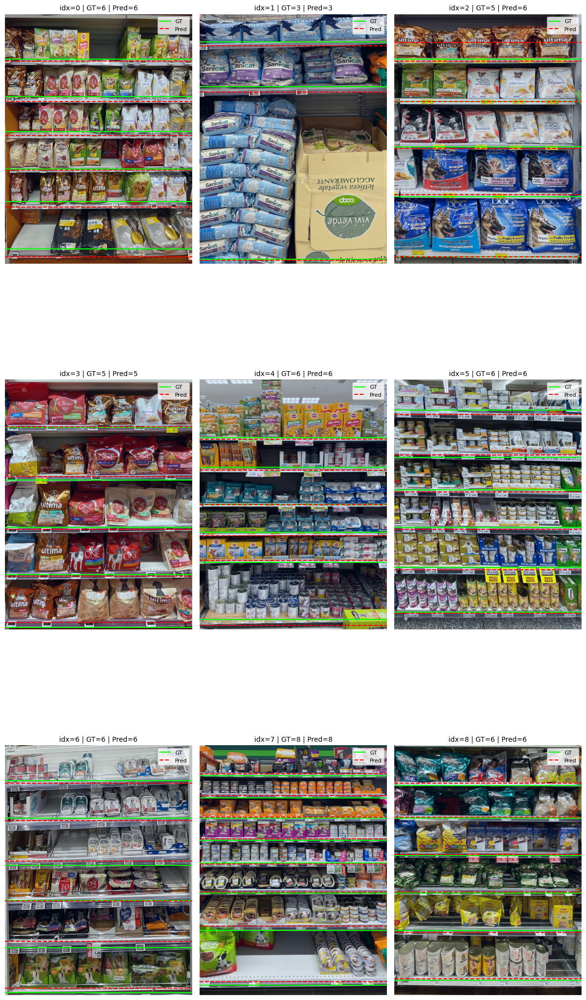

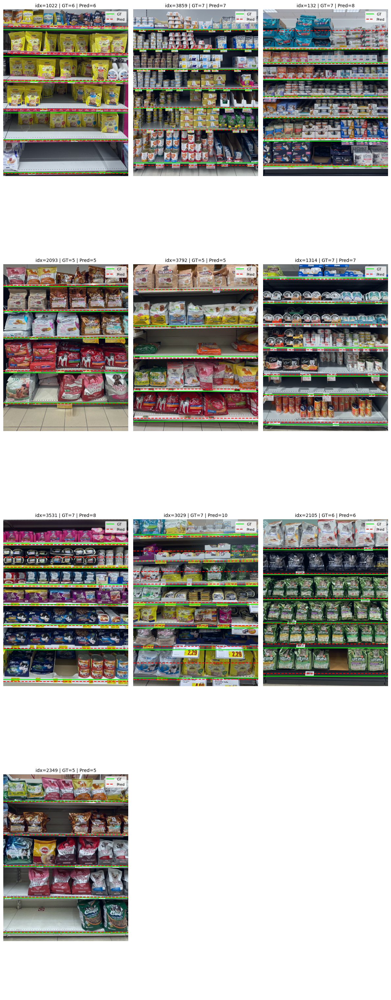

In [12]:
def visualize_grid(indices, ncols=3):
    n = len(indices)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 8*nrows))
    axes = np.array(axes).reshape(-1)  # đảm bảo luôn là mảng 1D dù nrows/ncols = 1

    model.eval()
    for ax, idx in zip(axes, indices):
        img, heatmap, gt_ys = val_ds[idx]
        with torch.no_grad():
            logits = model(img.unsqueeze(0).to(device))[0]
        pred_ys = extract_peaks(logits)

        img_np = img.permute(1, 2, 0).cpu().numpy()
        img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

        ax.imshow(img_np)
        for i, y in enumerate(gt_ys):
            ax.axhline(y * IMG_H, color='lime', linewidth=1.5, label='GT' if i == 0 else None)
        for i, y in enumerate(pred_ys):
            ax.axhline(y * IMG_H, color='red', linestyle='--', linewidth=1.5, label='Pred' if i == 0 else None)
        ax.set_title(f"idx={idx} | GT={len(gt_ys)} | Pred={len(pred_ys)}", fontsize=10)
        ax.axis('off')
        ax.legend(loc='upper right', fontsize=8)

    # ẩn các ô thừa nếu số ảnh không chia hết cho ncols
    for ax in axes[n:]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Ví dụ: xem 9 ảnh đầu tiên trong val set, chia lưới 3x3
visualize_grid(range(9), ncols=3)

# Hoặc xem ngẫu nhiên 6 ảnh bất kỳ trong val set
random_idx = np.random.choice(len(val_ds), size=10, replace=False)
visualize_grid(random_idx, ncols=3)